In [1]:
import logging
import os
import pdb
import re
import warnings
from pathlib import Path

import cartopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray
from sklearn.neighbors import BallTree as SKBallTree
from utils import na_values

warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

In [10]:
casedir = Path("/glade/campaign/mmm/parc/mwong/ufs-mrw")
workdir = Path("/glade/derecho/scratch/ahijevyc/ks21_tmp")

isensemble = False
# Choose a forecast length (24, 48, 72, or 240 work for deterministic fcsts)
forecast_length = 192 if isensemble else 48

datepos = 0
cases = sorted(casedir.glob(f"[12]?????????.F{forecast_length:03d}.C768"))
if isensemble:
    assert forecast_length in [192, 120], f"unexpected ensemble forecast_length {forecast_length}"
    cases = sorted(casedir.glob(f"E[12]?????????.p??.F{forecast_length:03d}.C768"))
    datepos = 1


# set extent
lon0 = -131
lon1 = -48
lat0 = 23
lat1 = 65

fmt = "%Y%m%d%H"
itimes = [pd.to_datetime(c.name[datepos : datepos + 10], format=fmt) for c in cases]
print(f"found {len(itimes)} itimes with {forecast_length}-h forecasts in casedir {casedir}")

# Choose an initialization time index
# 10 in Lupo2023
itimes_index = 10
itimes_index = itimes.index(pd.to_datetime("20200409T12")-pd.to_timedelta(forecast_length, "hour"))

logging.info(f"chose itime={itimes[itimes_index]}")

pd.Series(itimes, name="itime")

found 24 itimes with 48-h forecasts in casedir /glade/campaign/mmm/parc/mwong/ufs-mrw


0    2019-10-24 06:00:00
1    2019-11-25 06:00:00
2    2019-12-21 00:00:00
3    2020-02-10 06:00:00
4    2020-02-21 12:00:00
5    2020-03-02 00:00:00
6    2020-04-07 12:00:00
7    2020-04-10 12:00:00
8    2020-05-17 12:00:00
9    2020-08-30 18:00:00
10   2020-09-08 00:00:00
11   2020-10-26 18:00:00
12   2020-11-26 06:00:00
13   2021-03-15 18:00:00
14   2021-04-10 00:00:00
15   2021-04-12 12:00:00
16   2021-04-29 06:00:00
17   2021-10-17 18:00:00
18   2021-10-27 06:00:00
19   2022-01-01 06:00:00
20   2022-02-14 12:00:00
21   2022-04-12 06:00:00
22   2022-05-03 12:00:00
23   2022-06-12 18:00:00
Name: itime, dtype: datetime64[ns]

In [12]:
def xtime(ds: xarray.Dataset):
    """convert xtime variable to datetime and assign to coordinate"""

    # remove one-element-long Time dimension
    ds = ds.squeeze(dim="Time", drop=True)

    logging.info("decode initialization time variable")
    Time = pd.to_datetime(
        ds["Times"].load().item().decode("utf-8").strip(),
        format="%Y-%m-%d_%H:%M:%S",
    )

    # assign initialization time variable to its own coordinate
    ds = ds.assign_coords(
        Time=(
            ["Time"],
            [Time],
        ),
    )
    return ds

In [ ]:
parallel = False
if parallel:
    try:
        client.cluster.close()
        client.shutdown()
        client.close()
    except:
        pass
    
    from dask.distributed import Client
    client = Client(n_workers=8)
    client

In [66]:
%%time
for case in cases[itimes_index : itimes_index + 1]:
    ifiles = (case / "interp").glob("interp_fv3_history2d_??????????_f???.nc")
    ifiles = list(ifiles)
    ds = xarray.open_mfdataset(ifiles, preprocess=xtime, parallel=True, compat="override", coords="minimal")
logging.warning(f"opened {len(ifiles)} files")
logging.info(ifiles)

CPU times: user 41.5 s, sys: 28.9 s, total: 1min 10s
Wall time: 30.4 s


In [68]:
# Take 1-d lat and 1-d lon coordinates from 2-d XLONG and XLAT
lon = ds.XLONG.isel(south_north=0).values
#lon = np.roll(np.arange(-180, 180, 0.25)+0.25, 360*2+1)
lat = ds.XLAT.isel(west_east=0).values
#lat = np.linspace(90, -90, 180*4+1)
assert all(np.diff(lat) < 0), 'expected lat dimension in decreasing order'
ds = ds.rename_dims(south_north="lat", west_east="lon").assign_coords(lon=("lon",lon), lat=("lat",lat))
ds = ds.sel(lat = slice(lat1,lat0), lon=slice(lon0,lon1))

# group same variable from different levels into new variable with vertical dimension
potential_plevs = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50, 10]
for statevar in ["omg", "q", "rh", "t", "u", "v", "z"]:
    for tend in [
        "",
        "cnvgwd",
        "deepcnv",
        "lw",
        "mp",
        "nonphys",
        "ogwd",
        "pbl",
        "rdamp",
        "shalcnv",
        "sw",
    ]:
        potentialvars = [f"d{statevar}3dt{plev}_{tend}" for plev in potential_plevs]
        newvar = f"d{statevar}3dt_{tend}"
        if tend == "":
            potentialvars = [f"{statevar}{plev}" for plev in potential_plevs]
            newvar = statevar
        logging.info(newvar)
        this_vars = [var for var in potentialvars if var in ds]
        if not this_vars:
            continue
        stack = []
        for var in this_vars:
            logging.info(f"{var} {statevar} {tend}")
            plev = int(
                var.removeprefix(f"d{statevar}3dt")
                .removeprefix(statevar)
                .removesuffix(f"_{tend}")
            )
            assert plev, f"unexpected plev {plev}"
            tmpvar = ds[var].expand_dims(pfull=[plev])
            tmpvar.attrs["description"] = tmpvar.attrs["description"].lstrip(f"{plev}-mb ")
            stack.append(tmpvar)
            ds = ds.drop_vars(var)
        ds[newvar] = xarray.concat(stack, dim="pfull")
ds

<xarray.Dataset> Size: 1GB
Dimensions:        (Time: 8, lon: 333, lat: 169, pfull: 14)
Coordinates:
  * Time           (Time) datetime64[ns] 64B 2020-04-07T18:00:00 ... 2020-04-...
  * lon            (lon) float32 1kB -131.0 -130.8 -130.5 ... -48.5 -48.25 -48.0
  * lat            (lat) float32 676B 65.0 64.75 64.5 64.25 ... 23.5 23.25 23.0
  * pfull          (pfull) int64 112B 1000 925 850 700 600 ... 200 150 100 50 10
    XLONG          (lat, lon) float32 225kB dask.array<chunksize=(169, 333), meta=np.ndarray>
    XLAT           (lat, lon) float32 225kB dask.array<chunksize=(169, 333), meta=np.ndarray>
Data variables: (12/188)
    Times          (Time) |S19 152B b'2020-04-07_18:00:00' ... b'2020-04-09_1...
    us             (Time, lat, lon) float32 2MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    vs             (Time, lat, lon) float32 2MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    albdo_ave      (Time, lat, lon) float32 2MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    cprat_ave      (Time, lat, lon) float32 2MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    cpratb_ave     (Time, lat, lon) float32 2MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    ...             ...
    dv3dt_nonphys  (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_ogwd     (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_pbl      (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_rdamp    (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_shalcnv  (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    z              (pfull, Time, lat, lon) float32 25MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
Attributes: (12/17)
    WEST-EAST_GRID_DIMENSION:    1441
    SOUTH-NORTH_GRID_DIMENSION:  722
    BOTTOM-TOP_GRID_DIMENSION:   1
    SIMULATION_START_DATE:       2020-04-07_12:00:00
    START_DATE:                  2020-04-07_12:00:00
    VALID_TIME:                  2020-04-07_18:00:00
    ...                          ...
    MOAD_CEN_LAT:                0.0
    STAND_LON:                   0.0
    POLE_LAT:                    90.0
    POLE_LON:                    0.0
    MAP_PROJ:                    6
    MAP_PROJ_CHAR:               Lat/Lon

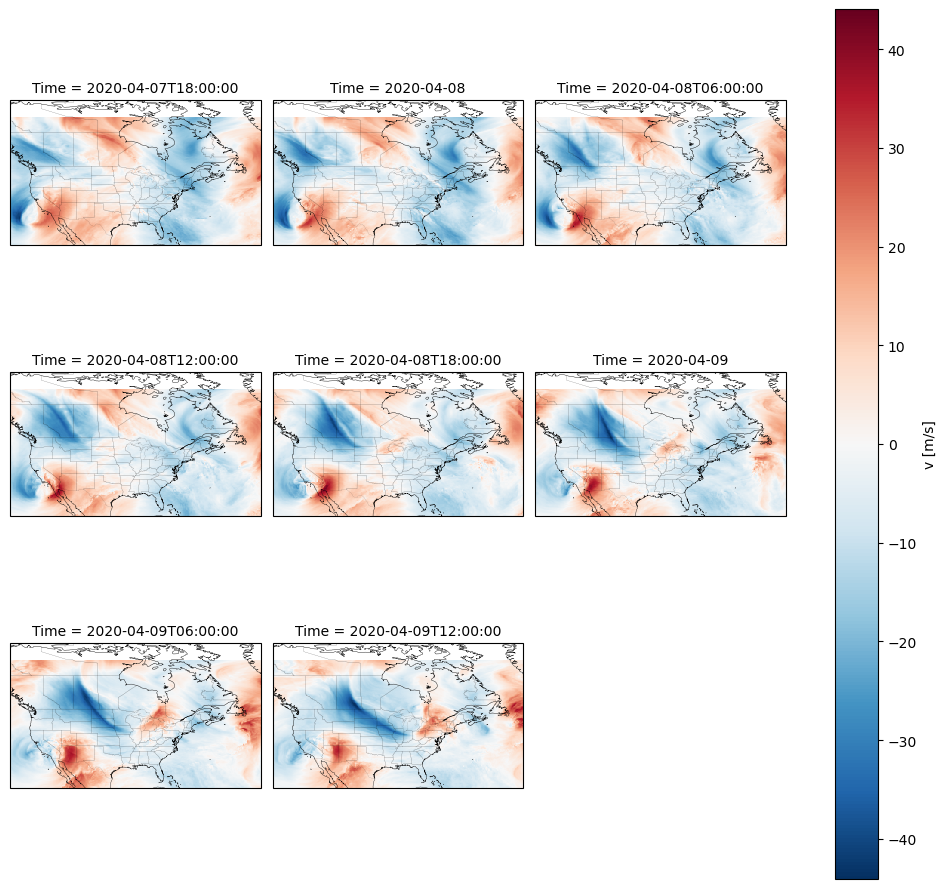

In [69]:
var = "v"
plev = 500
p = ds[var].sel(pfull=plev).plot(row="Time", col_wrap=3, subplot_kws={'projection': cartopy.crs.PlateCarree()}, transform=cartopy.crs.PlateCarree())
for ax in p.axs.flat:
    coastlines = ax.coastlines(lw=0.25)
    ax.add_feature(cartopy.feature.STATES, lw=0.1, alpha=0.5)
    ax.set_extent((lon0, lon1, lat0, lat1))

In [70]:
def getobs(itime, valid_time):
    obs_path = valid_time.strftime(
        "/glade/u/home/klupo/work_new/postdoc/kasugaEA21/version9/HGT_500mb/"
        f"gfs.0p25.%Y%m%d%H.f000.track"
    )
    obs = pd.read_csv(
        obs_path,
        header=0,
        sep=r"\s+",
        na_values=na_values,
    )
    return obs

def getfcst(itime, valid_time, workdir: Path):
    # workdirs is 1-element list for deterministic
    workdirs = [workdir / itime.strftime(fmt)]
    if isensemble:  # all the members
        workdirs = workdir.glob(f"E{itime.strftime(fmt)}.p??.*")
        alpha = 0.2

    fhr = (valid_time - itime) / pd.Timedelta(hours=1)

    fcst = []
    for workdir in workdirs:
        ifile = workdir / f"diag_TroughsCutoffs.{itime.strftime(fmt)}.f{fhr:03.0f}.track"
        print(".", end="")
        fcst.append(pd.read_csv(
            ifile,
            header=0,
            sep=r"\s+",
            na_values=na_values,
        ))
    return pd.concat(fcst)

def tissot(ax: plt.axes, df: pd.DataFrame, **kwargs) -> None:
    """
    Draw circle with Ro(km) radius around (LON(E), LAT(N)).
    Color is in "color" column.

    Parameters
    ----------
    ax : plt.axes
        axes to draw on
    df : pd.DataFrame
        DataFrame with columns ["Ro(km)", "LON(E)", "LAT(N)"]

    Returns
    -------
    None
    """

    for i, row in df.iterrows():
        t = ax.tissot(
            rad_km=row["Ro(km)"],
            lons=row["LON(E)"],
            lats=row["LAT(N)"],
            **kwargs,
        )
    return



........

Text(0.5, 0.98, 'init time: 2020-04-07 12:00:00')

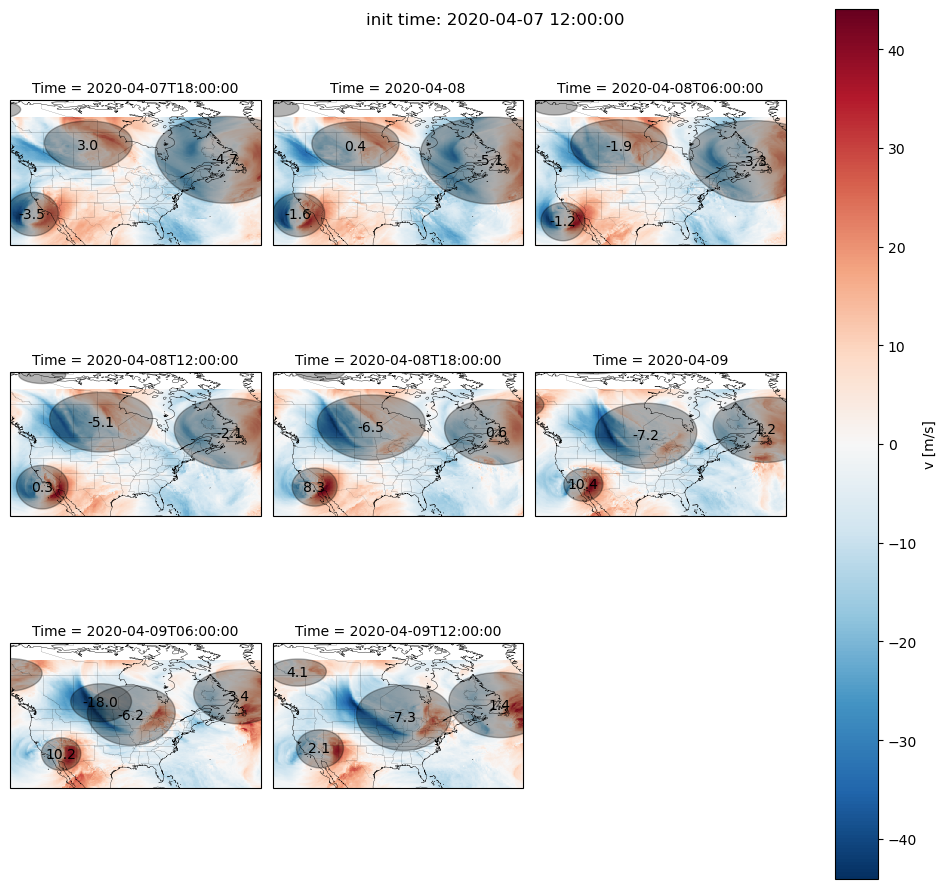

In [74]:
# stack 1-d 'pt' coordinate from lat and lon 
# so we can use 1-d indices returned from SKBallTree query_radius
ds_pt = ds.stack(pt=("lat", "lon"))

X = np.deg2rad(np.c_[ds_pt.XLAT, ds_pt.XLONG])
tree = SKBallTree(X, metric="haversine")
initialization_time = pd.to_datetime(ds_pt.Time)[0] - pd.to_timedelta(6, unit="hour")

p = ds[var].sel(pfull=plev).plot(row="Time", col_wrap=3, subplot_kws={'projection': cartopy.crs.PlateCarree()}, transform=cartopy.crs.PlateCarree())
for valid_time, ax in zip(ds_pt.Time.values, p.axs.flat):
    coastlines = ax.coastlines(lw=0.25)
    ax.add_feature(cartopy.feature.STATES, lw=0.1, alpha=0.5)
    ax.set_extent((lon0, lon1, lat0, lat1))

    valid_time = pd.to_datetime(valid_time)
    fhr = (valid_time - initialization_time) / pd.Timedelta(hours=1)
    
    obs = getobs(initialization_time, valid_time)
    fcst = getfcst(initialization_time, valid_time, workdir)
    
    for i, row in fcst.iterrows():
        lat = row["LAT(N)"]
        lon = row["LON(E)"]
        if lon >= 180:
            lon = lon - 360
        if lon < lon0:
            continue
        if lon >= lon1:
            continue
        if lat < lat0:
            continue
        if lat >= lat1:
            continue
        r = np.deg2rad(row["Ro(km)"] / 111.0)
        # List pts closest to each latlon element
        (idx,) = tree.query_radius(
            np.deg2rad([[lat, lon]]), r=r, return_distance=False
        )
        inblob = ds_pt[var].isel(pt=idx).sel(Time=valid_time).sel(pfull=plev)
        avg = inblob.compute().mean().compute().data
        wgt = np.cos(np.deg2rad(inblob.lat))
        wgtavg = ((inblob * wgt).sum() / wgt.sum()).compute().data
        fcst.loc[i, "avg"] = wgtavg
        logging.info(f"{lat}, {lon}: {avg} {wgtavg}")
        ax.text(lon, lat, f"{wgtavg:.1f}", ha="center", va="center", transform=cartopy.crs.PlateCarree())
        # values = ds_pt[var].values
        # values[..., idx] = np.nan # blank out blob data for debugging
        # ds_pt[var] = xarray.DataArray(values, coords=ds_pt[var].coords)
    
    # tissot(ax, obs, alpha=0.4, color="green")
    alpha = 0.3
    tissot(ax, fcst, alpha=alpha, color="k")    
ds_pt = ds_pt.unstack()
p.fig.suptitle(f"init time: {initialization_time}")

In [14]:
fcst

,ITIME,FHOUR,ID,So(m/100km),LAT(N),LON(E),SoFlag,Ro(km),SR,BGo(m/100km),...,FERRY(km),FERRX(km),FERR(km),T(0)/M(1)/N,VLat(N),VLon(E),VSo,VRo,VZmin,avg
0,2020040512,f024,35490.0,18.32,76.25,151.00,0,500.0,0.66,12.13,...,55.61,0.00,55.61,0,75.75,151.00,17.30,500.0,4993.99,NaN
1,2020040512,f024,35584.0,17.24,67.75,209.00,0,400.0,0.43,7.34,...,111.23,120.73,162.34,0,66.75,206.25,16.24,500.0,5024.04,NaN
2,2020040512,f024,35613.0,16.49,63.25,304.25,0,400.0,1.39,22.94,...,0.00,0.00,0.00,0,63.25,304.25,17.60,400.0,5054.75,-13.110860
3,2020040512,f024,35516.0,14.32,62.00,149.25,0,400.0,1.32,18.96,...,0.00,26.11,26.11,0,62.00,148.75,13.84,300.0,NaN,NaN
4,2020040512,f024,35611.0,25.23,62.00,334.50,0,1200.0,0.50,12.58,...,-27.81,-38.84,47.90,0,62.25,335.25,23.93,1200.0,4975.55,NaN
5,2020040512,f024,35623.0,13.09,60.50,212.50,0,300.0,2.21,28.90,...,27.81,151.77,153.72,1,60.25,209.75,14.75,500.0,NaN,NaN
6,2020040512,f024,35624.0,14.58,60.50,229.25,1,300.0,1.26,18.32,...,-27.81,13.59,30.97,1,60.75,229.00,13.36,300.0,5174.26,2.866868
7,2020040512,f024,35612.0,13.41,58.75,182.50,0,600.0,1.72,23.13,...,0.00,28.85,28.85,0,58.75,182.00,13.69,600.0,NaN,NaN
8,2020040512,f024,35550.0,14.59,55.75,244.50,0,800.0,0.88,12.83,...,83.42,0.00,83.42,0,55.00,244.50,15.55,700.0,NaN,1.286986
9,2020040512,f024,35583.0,15.50,50.50,99.75,0,400.0,0.34,5.19,...,-55.61,0.00,55.61,0,51.00,99.75,15.80,400.0,5507.63,NaN


In [35]:
import re
pattern = re.compile(r'^d(\w)3dt(\d+)_(\w+)$')
var, plev, tend = re.search(pattern, "dq3dt200_deepcnv").groups()

error: unknown extension ?) at position 3

In [78]:
plevs.drop(600)

Index([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100], dtype='int64', name='pfull')